In [8]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from src.modeling import (
    run_experiment,
    tune_model,
    compare_models,
    cross_validate_best_config,
    plot_strategy_comparison,
    plot_ratio_impact,
    plot_all_confusion_matrices,
    plot_precision_recall_curve,
    plot_roc_curve,
    ModelingPreparer
)

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


#### LOAD DATA

In [2]:
df_ecomm = pd.read_csv('../data/processed/ecommerce_processed.csv')
df_credit = pd.read_csv('../data/processed/creditcard_cleaned.csv')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"E-commerce: {df_ecomm.shape}, Fraud rate: {df_ecomm['class'].mean()*100:.2f}%")
print(f"Credit Card: {df_credit.shape}, Fraud rate: {df_credit['Class'].mean()*100:.4f}%")

DATA LOADED
E-commerce: (151112, 19), Fraud rate: 9.36%
Credit Card: (283726, 31), Fraud rate: 0.1667%


In [5]:
print("\n" + "="*60)
print("DATA SEGREGATION FOR DYNAMIC TUNING")
print("="*60)

# Get operational training and testing splits safely
preparer = ModelingPreparer(target_col='class')
X_train, X_test, y_train, y_test = preparer.prepare_splits(df_ecomm)

# Isolating a clean cross-validation tuning split to protect the test set
X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Data splits prepared. Hyperparameters will be dynamically optimized per resampling ratio.")


DATA SEGREGATION FOR DYNAMIC TUNING
Data splits prepared. Hyperparameters will be dynamically optimized per resampling ratio.


## E-COMMERCE MODELING AND EXPERIMENTS

In [6]:
print("\n" + "="*70)
print("E-COMMERCE EXPERIMENTS")
print("="*70)

ecomm_results = []

# 1. Baseline (Logistic Regression)
print("\nBASELINE (No Resampling)")
print("-" * 55)
result = run_experiment(df_ecomm, 'class', strategy='none', model_type='logistic', threshold=0.30)
ecomm_results.append(result)
print(f"    F1: {result['f1_score']:.4f} | Precision: {result['precision']:.4f} | Recall: {result['recall']:.4f} | AUPRC: {result['auprc']:.4f}")
print(f"    Train: {result['train_shape'][0]:,} | Test: {result['test_shape'][0]:,}")


# 2. SMOTE Experiments
print("\nSMOTE EXPERIMENTS")
print("-" * 75)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8} {'After Ratio':<12}")
print("-" * 65)

for ratio in [0.2, 0.33, 0.5, 0.75, 1.0]:
    # --- Dynamic Tuning Pass ---
    # Apply SMOTE at the current ratio loop strictly to the training tuning slice
    from imblearn.over_sampling import SMOTE
    sampler = SMOTE(sampling_strategy=ratio, random_state=42)
    X_tr_res, y_tr_res = sampler.fit_resample(X_train_tune, y_train_tune)
    
    # Extract optimized parameters for this specific distribution
    tuned_params = tune_model(X_tr_res, y_tr_res, X_val_tune, y_val_tune, model_type='xgboost', threshold=0.30)
    
    # Run the structural experiment using the dynamically generated parameters
    result = run_experiment(
        df=df_ecomm, 
        target_col='class', 
        strategy='smote', 
        target_ratio=ratio, 
        model_type='xgboost', 
        threshold=0.30,
        model_params=tuned_params  # <-- Passes tuned max_depth and learning_rate parameters
    )
    ecomm_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f} {result['after_ratio']:<12}")

# Best SMOTE Extraction
best_smote = max([r for r in ecomm_results if r['strategy'] == 'smote'], key=lambda x: x['f1_score'])
print(f"\nBest SMOTE: Ratio={best_smote['target_ratio']}, F1={best_smote['f1_score']:.4f}, Precision={best_smote['precision']:.4f}, Recall={best_smote['recall']:.4f}")


# 3. Undersampling Experiments
print("\nUNDERSAMPLING EXPERIMENTS")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75, 1.0]:
    # --- Dynamic Tuning Pass ---
    # Apply Undersampling at the current ratio loop strictly to the training tuning slice
    from imblearn.under_sampling import RandomUnderSampler
    sampler = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_tr_res, y_tr_res = sampler.fit_resample(X_train_tune, y_train_tune)
    
    # Extract optimized parameters for this specific undersampled distribution
    tuned_params = tune_model(X_tr_res, y_tr_res, X_val_tune, y_val_tune, model_type='xgboost', threshold=0.30)
    
    # Run structural experiment
    result = run_experiment(
        df=df_ecomm, 
        target_col='class', 
        strategy='undersample', 
        target_ratio=ratio, 
        model_type='xgboost', 
        threshold=0.30,
        model_params=tuned_params  # <-- Passes tuned parameters for undersampling environment
    )
    ecomm_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


E-COMMERCE EXPERIMENTS

BASELINE (No Resampling)
-------------------------------------------------------
    F1: 0.4208 | Precision: 0.2939 | Recall: 0.7403 | AUPRC: 0.6668
    Train: 120,889 | Test: 30,223

SMOTE EXPERIMENTS
---------------------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC    After Ratio 
-----------------------------------------------------------------
Best XGBOOST params at threshold 0.3: {'max_depth': 4, 'learning_rate': 0.1} (Validation F1: 0.7082)
0.20     0.6880   0.8535     0.5763   0.7068   1:5.0       
Best XGBOOST params at threshold 0.3: {'max_depth': 4, 'learning_rate': 0.2} (Validation F1: 0.7099)
0.33     0.6785   0.8133     0.5820   0.7064   1:3.0       
Best XGBOOST params at threshold 0.3: {'max_depth': 6, 'learning_rate': 0.2} (Validation F1: 0.6964)
0.50     0.6659   0.7628     0.5908   0.7065   1:2.0       
Best XGBOOST params at threshold 0.3: {'max_depth': 8, 'learning_rate': 0.2} (Validation

#### RANDOM FOREST EXPERIMENTS (Ensemble Model 2)

In [7]:
print("\n" + "="*70)
print("RANDOM FOREST EXPERIMENTS WITH DYNAMIC PARAMETER TUNING")
print("="*70)

rf_results = []

# 1. Random Forest with SMOTE
print("\nRANDOM FOREST + SMOTE")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75]:
    # --- Dynamic Tuning Pass ---
    # Apply SMOTE at the current ratio loop strictly to the training tuning slice
    sampler = SMOTE(sampling_strategy=ratio, random_state=42)
    X_tr_res, y_tr_res = sampler.fit_resample(X_train_tune, y_train_tune)
    
    # Extract optimized Random Forest parameters for this specific SMOTE distribution
    tuned_params = tune_model(X_tr_res, y_tr_res, X_val_tune, y_val_tune, model_type='random_forest', threshold=0.30)
    
    # Run the structural experiment using the dynamically generated parameters
    result = run_experiment(
        df=df_ecomm, 
        target_col='class', 
        strategy='smote', 
        target_ratio=ratio, 
        model_type='random_forest', 
        threshold=0.30,
        model_params=tuned_params  # <-- Passes tuned max_depth and n_estimators
    )
    rf_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


# 2. Random Forest with Undersampling
print("\nRANDOM FOREST + UNDERSAMPLING")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75]:
    # --- Dynamic Tuning Pass ---
    # Apply Undersampling at the current ratio loop strictly to the training tuning slice
    sampler = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_tr_res, y_tr_res = sampler.fit_resample(X_train_tune, y_train_tune)
    
    # Extract optimized Random Forest parameters for this specific undersampled distribution
    tuned_params = tune_model(X_tr_res, y_tr_res, X_val_tune, y_val_tune, model_type='random_forest', threshold=0.30)
    
    # Run structural experiment
    result = run_experiment(
        df=df_ecomm, 
        target_col='class', 
        strategy='undersample', 
        target_ratio=ratio, 
        model_type='random_forest', 
        threshold=0.30,
        model_params=tuned_params 
    )
    rf_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


RANDOM FOREST EXPERIMENTS WITH DYNAMIC PARAMETER TUNING

RANDOM FOREST + SMOTE
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
--------------------------------------------------
Best RANDOM_FOREST params at threshold 0.3: {'max_depth': 15, 'n_estimators': 200} (Validation F1: 0.7043)
0.20     0.5982   0.5217     0.7011   0.7044  
Best RANDOM_FOREST params at threshold 0.3: {'max_depth': 5, 'n_estimators': 100} (Validation F1: 0.6935)
0.33     0.1752   0.0962     0.9855   0.7035  
Best RANDOM_FOREST params at threshold 0.3: {'max_depth': 15, 'n_estimators': 100} (Validation F1: 0.6107)
0.50     0.5984   0.5220     0.7011   0.7064  
Best RANDOM_FOREST params at threshold 0.3: {'max_depth': 15, 'n_estimators': 100} (Validation F1: 0.6091)
0.75     0.5983   0.5218     0.7011   0.7062  

RANDOM FOREST + UNDERSAMPLING
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
-------

In [9]:
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
compare_models(ecomm_results)
compare_models(rf_results)


MODEL COMPARISON TABLE

Model           Strategy     F1       Precision  Recall   AUPRC   
------------------------------------------------------------------------------------------
LOGISTIC        none         0.4208   0.2939     0.7403   0.6668  
XGBOOST         smote        0.6880   0.8535     0.5763   0.7068  
XGBOOST         smote        0.6785   0.8133     0.5820   0.7064  
XGBOOST         smote        0.6659   0.7628     0.5908   0.7065  
XGBOOST         smote        0.6632   0.7652     0.5852   0.7048  
XGBOOST         smote        0.6598   0.7454     0.5919   0.7035  
XGBOOST         undersample  0.6369   0.6336     0.6403   0.7023  
XGBOOST         undersample  0.6089   0.5424     0.6940   0.7046  
XGBOOST         undersample  0.6070   0.5375     0.6972   0.7064  
XGBOOST         undersample  0.6053   0.5342     0.6982   0.7061  
XGBOOST         undersample  0.5875   0.5053     0.7014   0.7061  

Model           Strategy     F1       Precision  Recall   AUPRC   
------------

In [10]:
print("\n" + "="*60)
print("CROSS-VALIDATION")
print("="*60)

cv_results = cross_validate_best_config(df_ecomm, 'class', ecomm_results, cv=5, threshold=0.30)
print(f"\nCross-validation Results:")
print(f"  F1 Score: {cv_results['cv_f1_mean']:.4f} ± {cv_results['cv_f1_std']:.4f}")
print(f"  AUPRC: {cv_results['cv_auprc_mean']:.4f} ± {cv_results['cv_auprc_std']:.4f}")


CROSS-VALIDATION
Rigorous Cross-Validating: Model=XGBOOST | Strategy=SMOTE | Ratio=0.2 | Threshold=0.3

Cross-validation Results:
  F1 Score: 0.6988 ± 0.0081
  AUPRC: 0.7219 ± 0.0059


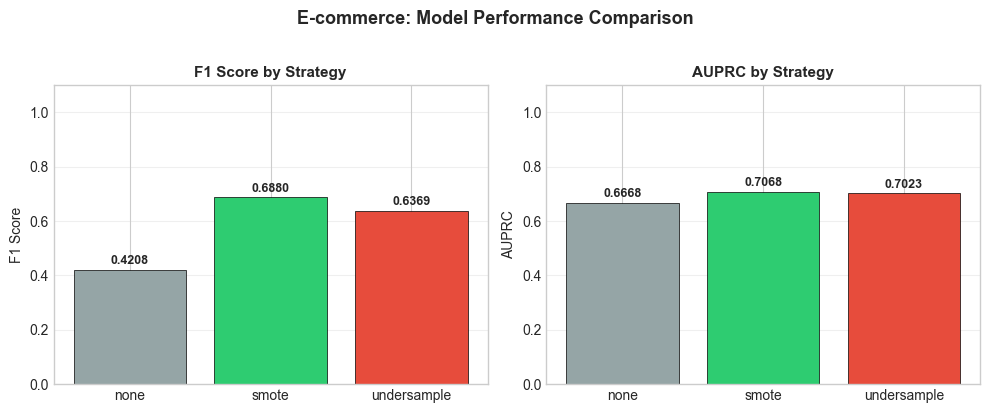

In [12]:
# Strategy comparison bar chart
plot_strategy_comparison(ecomm_results, "E-commerce", "../models/ecomm_comparison")

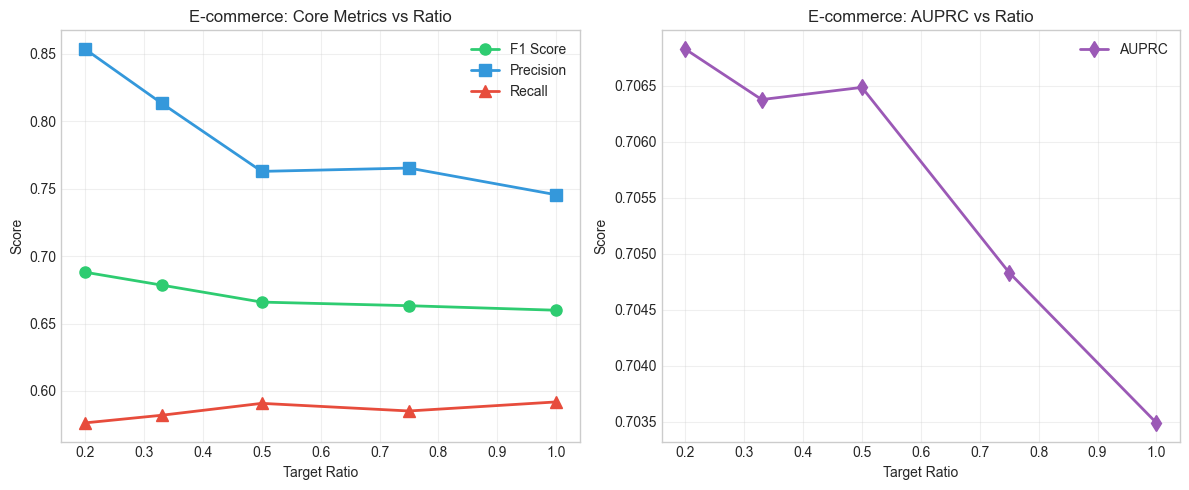

In [13]:
plot_ratio_impact(ecomm_results, "E-commerce", strategy='smote', save_path="../models/ecomm_smote_impact.png")

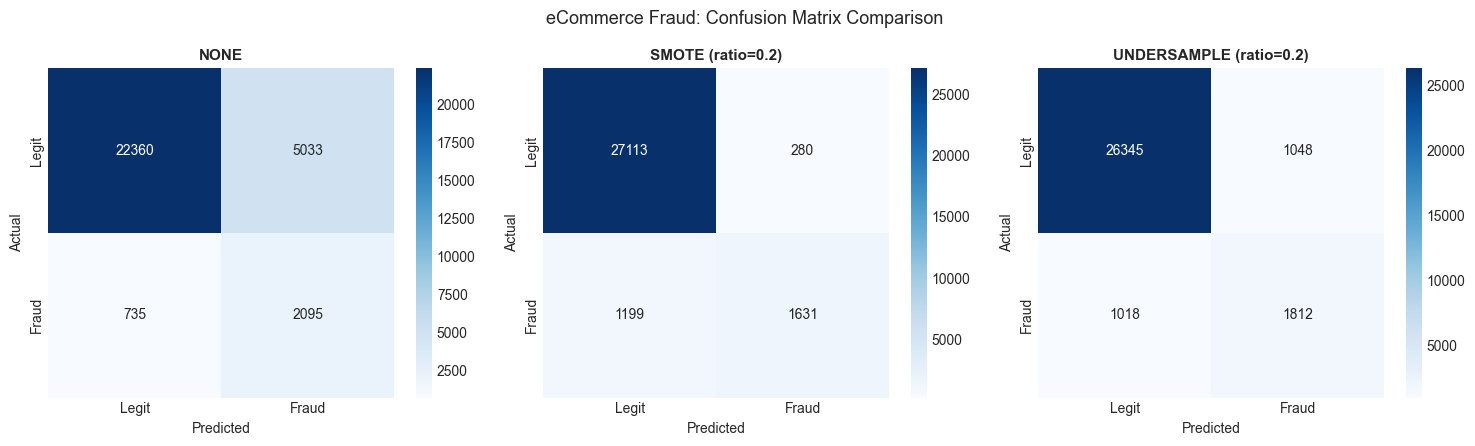

In [14]:
plot_all_confusion_matrices(
    results_list=ecomm_results, 
    dataset_name="eCommerce Fraud"
)

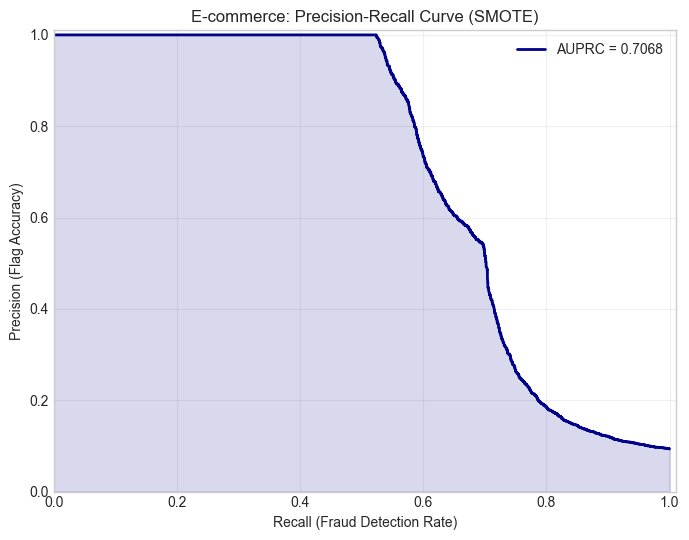

In [15]:
best_model = max(ecomm_results, key=lambda x: x['f1_score'])
preparer = ModelingPreparer(target_col='class')
_, X_test, _, y_test = preparer.prepare_splits(df_ecomm)
plot_precision_recall_curve(best_model, X_test, y_test, "E-commerce", "../models/ecomm_pr_curve.png")

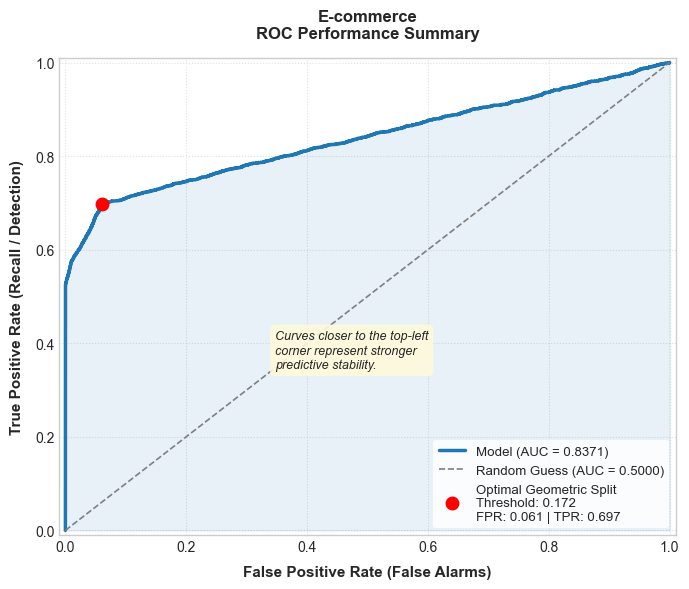

In [16]:
plot_roc_curve(best_model, X_test, y_test, "E-commerce")

## CREDIT CARD MODELING AND EXPERIMENTS

In [20]:
df_credit = df_credit.rename(columns={'Class': 'class'})

print(f"Credit Card Data: {df_credit.shape}")
print(f"Fraud rate: {df_credit['class'].mean()*100:.4f}% ({df_credit['class'].sum():,} fraud out of {len(df_credit):,})")

Credit Card Data: (283726, 31)
Fraud rate: 0.1667% (473 fraud out of 283,726)


In [19]:
print("\n" + "="*60)
print("2. MODEL EXPERIMENTS")
print("="*60)

credit_results = []

# Baseline (Logistic Regression)
print("\n>>> BASELINE (No Resampling)")
print("-" * 55)
result = run_experiment(df_credit, 'class', strategy='none', model_type='logistic', threshold=0.50)
credit_results.append(result)
print(f"   F1: {result['f1_score']:.4f} | Precision: {result['precision']:.4f} | Recall: {result['recall']:.4f} | AUPRC: {result['auprc']:.4f}")

# SMOTE Experiments (using smaller ratios due to extreme imbalance)
print("\n>>> SMOTE EXPERIMENTS")
print("-" * 75)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8} {'After Ratio':<12}")
print("-" * 65)

for ratio in [0.05, 0.1, 0.2, 0.33, 0.5]:
    result = run_experiment(df_credit, 'class', strategy='smote', target_ratio=ratio, 
                           model_type='xgboost', threshold=0.50)
    credit_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f} {result['after_ratio']:<12}")

# Undersampling (for comparison)
print("\n>>> UNDERSAMPLING EXPERIMENTS")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.1, 0.2, 0.33, 0.5]:
    result = run_experiment(df_credit, 'class', strategy='undersample', target_ratio=ratio, 
                           model_type='xgboost', threshold=0.50)
    credit_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


2. MODEL EXPERIMENTS

>>> BASELINE (No Resampling)
-------------------------------------------------------
   F1: 0.1059 | Precision: 0.0564 | Recall: 0.8737 | AUPRC: 0.7046

>>> SMOTE EXPERIMENTS
---------------------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC    After Ratio 
-----------------------------------------------------------------
0.05     0.8177   0.8605     0.7789   0.8081   1:20.0      
0.10     0.7604   0.7526     0.7684   0.8096   1:10.0      
0.20     0.7264   0.6581     0.8105   0.8059   1:5.0       
0.33     0.6756   0.5846     0.8000   0.7944   1:3.0       
0.50     0.6185   0.5000     0.8105   0.7898   1:2.0       

>>> UNDERSAMPLING EXPERIMENTS
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
--------------------------------------------------
0.10     0.5552   0.4194     0.8211   0.6984  
0.20     0.4124   0.2730     0.8421   0.7344  
0.33     0.3028 

#### HYPERPARAMETER TUNING

In [21]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING (CREDIT CARD)")
print("="*60)

# Get credit data for tuning
preparer_credit = ModelingPreparer(target_col='class')
X_train_c, X_test_c, y_train_c, y_test_c = preparer_credit.prepare_splits(df_credit)

# Split train further for validation
X_train_tune_c, X_val_tune_c, y_train_tune_c, y_val_tune_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42, stratify=y_train_c
)

# Tune XGBoost parameters
best_params_credit = tune_model(X_train_tune_c, y_train_tune_c, X_val_tune_c, y_val_tune_c, model_type='xgboost', threshold=0.50)
print(f"\n Using best params: {best_params_credit} for final model")


HYPERPARAMETER TUNING (CREDIT CARD)
Best XGBOOST params at threshold 0.5: {'max_depth': 8, 'learning_rate': 0.05} (Validation F1: 0.8857)

 Using best params: {'max_depth': 8, 'learning_rate': 0.05} for final model


In [22]:
print("\n" + "="*60)
print("MODEL COMPARISON TABLE (CREDIT CARD)")
print("="*60)
compare_models(credit_results)


MODEL COMPARISON TABLE (CREDIT CARD)

Model           Strategy     F1       Precision  Recall   AUPRC   
------------------------------------------------------------------------------------------
LOGISTIC        none         0.1059   0.0564     0.8737   0.7046  
XGBOOST         smote        0.8177   0.8605     0.7789   0.8081  
XGBOOST         smote        0.7604   0.7526     0.7684   0.8096  
XGBOOST         smote        0.7264   0.6581     0.8105   0.8059  
XGBOOST         smote        0.6756   0.5846     0.8000   0.7944  
XGBOOST         smote        0.6185   0.5000     0.8105   0.7898  
XGBOOST         undersample  0.5552   0.4194     0.8211   0.6984  
XGBOOST         undersample  0.4124   0.2730     0.8421   0.7344  
XGBOOST         undersample  0.3028   0.1841     0.8526   0.6877  
XGBOOST         undersample  0.2207   0.1268     0.8526   0.6656  


CROSS-VALIDATION (CREDIT CARD)

In [23]:
print("\n" + "="*60)
print("CROSS-VALIDATION (CREDIT CARD)")
print("="*60)

# Validate the top performing configuration (SMOTE ratio 0.05, Threshold 0.50)
cv_results_credit = cross_validate_best_config(df_credit, 'class', credit_results, cv=5, threshold=0.50)
print(f"\nCross-validation Results:")
print(f"  F1 Score: {cv_results_credit['cv_f1_mean']:.4f} ± {cv_results_credit['cv_f1_std']:.4f}")
print(f"  AUPRC: {cv_results_credit['cv_auprc_mean']:.4f} ± {cv_results_credit['cv_auprc_std']:.4f}")


CROSS-VALIDATION (CREDIT CARD)
Rigorous Cross-Validating: Model=XGBOOST | Strategy=SMOTE | Ratio=0.05 | Threshold=0.5

Cross-validation Results:
  F1 Score: 0.8363 ± 0.0141
  AUPRC: 0.8393 ± 0.0281


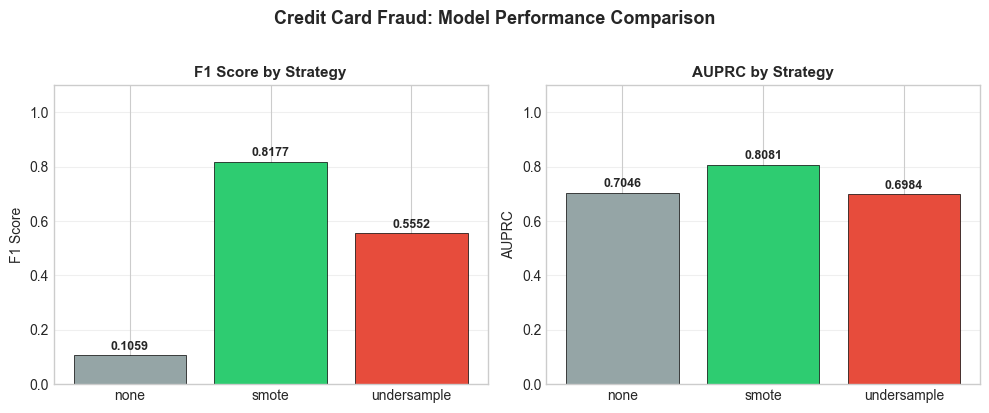

In [28]:
plot_strategy_comparison(credit_results, dataset_name="Credit Card Fraud")

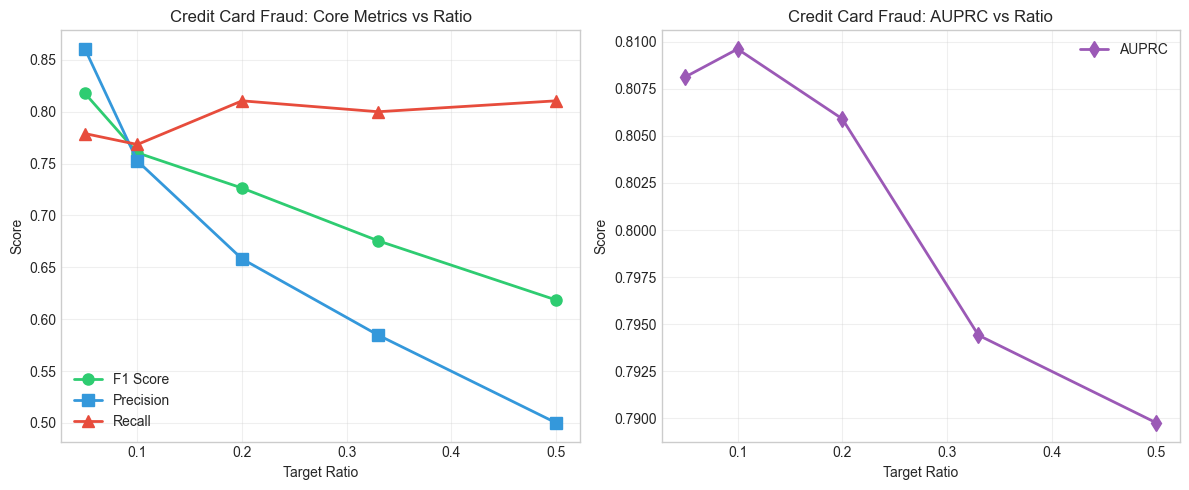

In [ ]:
plot_ratio_impact(credit_results, dataset_name="Credit Card Fraud", strategy="smote")


GENERATING CONFUSION MATRICES


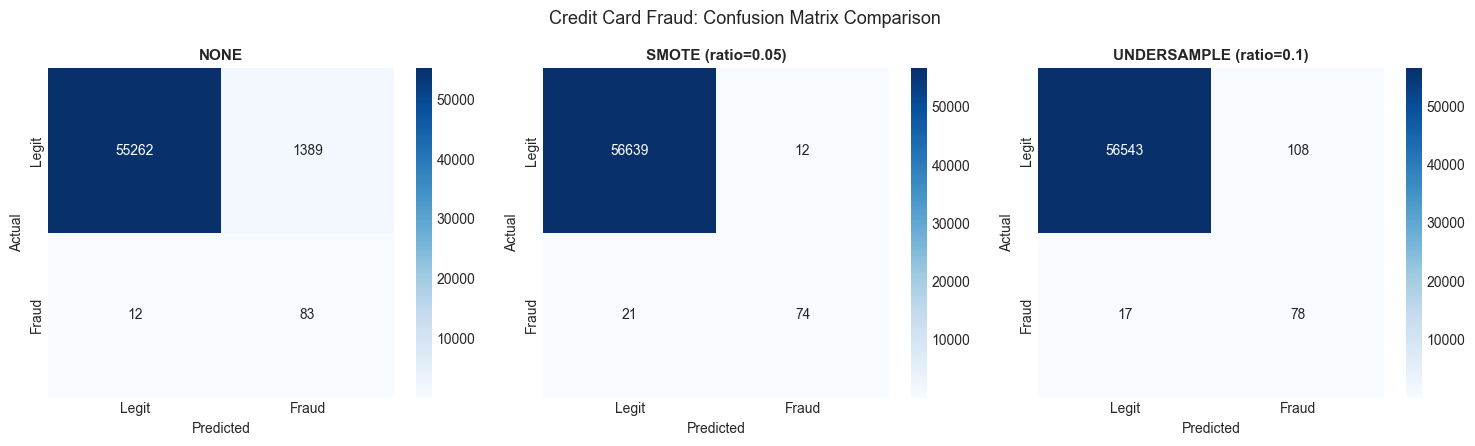

In [26]:
print("\n" + "="*60)
print("GENERATING CONFUSION MATRICES")
print("="*60)

# Compare the best confusion matrices across strategies side-by-side
plot_all_confusion_matrices(credit_results, dataset_name="Credit Card Fraud")


GENERATING PR & ROC PERFORMANCE CURVES
Plotting curves for Best Configuration: Strategy=SMOTE | Ratio=0.05


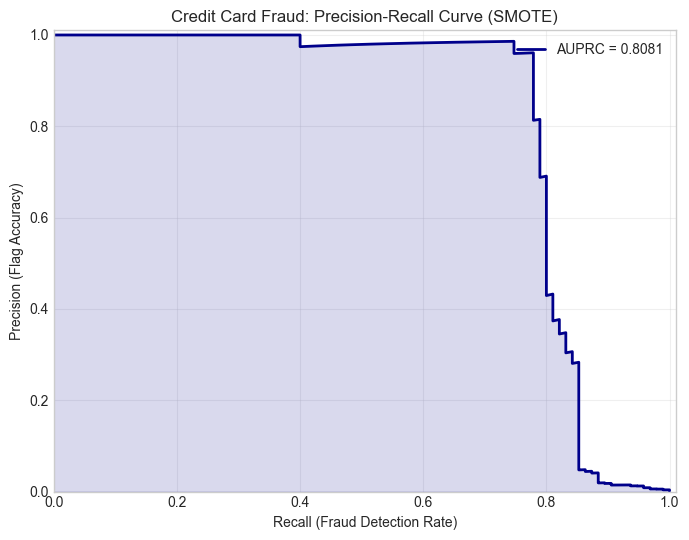

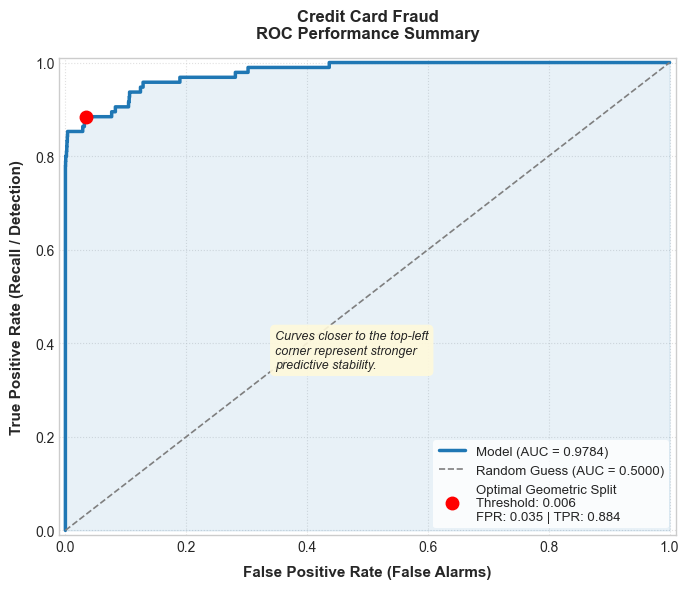

In [27]:
print("\n" + "="*60)
print("GENERATING PR & ROC PERFORMANCE CURVES")
print("="*60)

# Find the absolute best individual experiment result (which should be SMOTE Ratio=0.05)
best_overall_result_credit = max(credit_results, key=lambda x: x['f1_score'])

print(f"Plotting curves for Best Configuration: Strategy={best_overall_result_credit['strategy'].upper()} | Ratio={best_overall_result_credit.get('target_ratio', 'N/A')}")

# Generate Precision-Recall Curve
plot_precision_recall_curve(
    best_overall_result_credit, 
    X_test_c, 
    y_test_c, 
    dataset_name="Credit Card Fraud", 
)

# Generate ROC Curve
plot_roc_curve(
    best_overall_result_credit, 
    X_test_c, 
    y_test_c, 
    dataset_name="Credit Card Fraud", 
)